In [1]:
#Import necesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA

## Exploratory Data Analysis (EDA)

In [2]:
# Load dataset
df = pd.read_csv("mushroom.csv")
df.head()

,Unnamed: 0,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat,class,stalk_height,cap_diameter
0,1167,sunken,scaly,white,no,anise,descending,distant,broad,pink,...,partial,brown,two,sheathing,chocolate,clustered,waste,poisonous,14.276173,5.054983
1,1037,sunken,fibrous,red,no,anise,notched,crowded,narrow,chocolate,...,universal,brown,two,sheathing,brown,numerous,waste,edible,3.952715,19.068319
2,309,flat,grooves,purple,yes,foul,descending,crowded,broad,purple,...,universal,yellow,two,sheathing,purple,abundant,waste,poisonous,9.054265,7.205884
3,282,bell,scaly,pink,yes,fishy,notched,close,broad,orange,...,partial,yellow,two,cobwebby,green,clustered,grasses,poisonous,5.226499,20.932692
4,820,flat,smooth,yellow,yes,musty,free,crowded,narrow,orange,...,universal,white,none,none,yellow,clustered,urban,poisonous,14.037532,12.545245


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (2000, 26)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                2000 non-null   int64  
 1   cap_shape                 2000 non-null   object 
 2   cap_surface               2000 non-null   object 
 3   cap_color                 2000 non-null   object 
 4   bruises                   2000 non-null   object 
 5   odor                      2000 non-null   object 
 6   gill_attachment           2000 non-null   object 
 7   gill_spacing              2000 non-null   object 
 8   gill_size                 2000 non-null   object 
 9   gill_color                2000 non-null   object 
 10  stalk_shape               2000 non-null   object 
 11  stalk_root                2000 non-null   object 
 12  stalk_surface_above_ring  2000 non-null   object 
 13  stalk_surface_below_ring  2000 non-null   object 
 14  stalk_co

In [5]:
#Checking  missing values
df.isnull().sum()

Unnamed: 0                  0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
class                       0
stalk_height                0
cap_diameter                0
dtype: int64

In [6]:
df["class"].value_counts()

class
poisonous    1400
edible        600
Name: count, dtype: int64

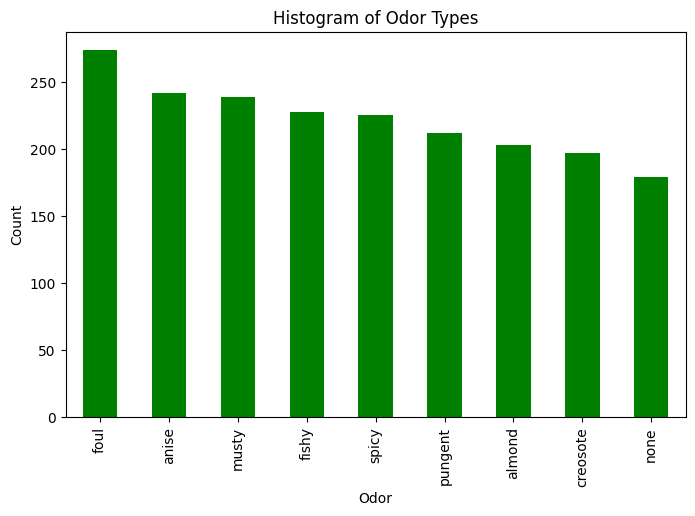

In [7]:
# Histogram example (odor distribution)
plt.figure(figsize=(8,5))
df['odor'].value_counts().plot(kind="bar", color="green")
plt.title("Histogram of Odor Types")
plt.xlabel("Odor")
plt.ylabel("Count")
plt.show()

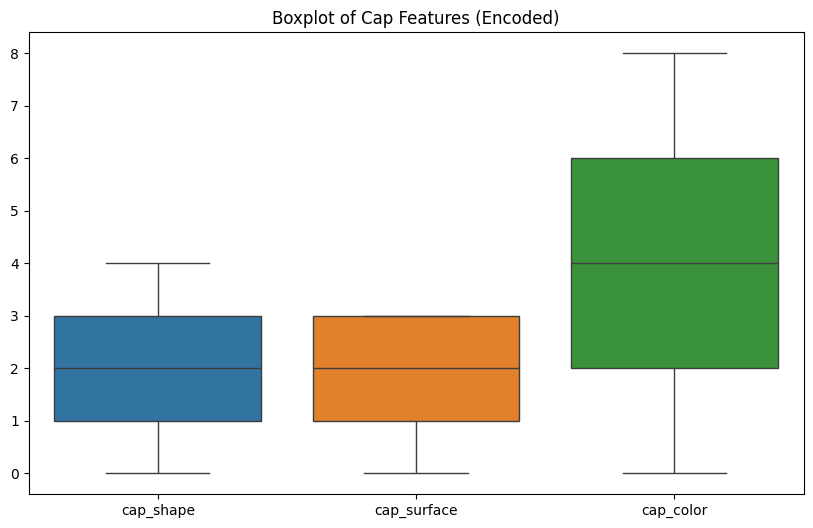

In [8]:
# Boxplot example (encoded features to visualize spread)
df_encoded = df.apply(LabelEncoder().fit_transform)
plt.figure(figsize=(10,6))
sns.boxplot(data=df_encoded[['cap_shape','cap_surface','cap_color']])
plt.title("Boxplot of Cap Features (Encoded)")
plt.show()


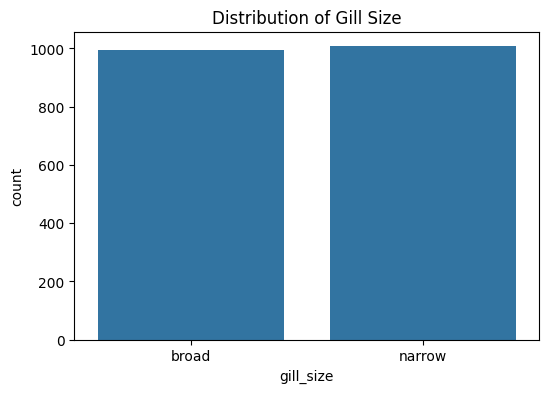

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x="gill_size", data=df)
plt.title("Distribution of Gill Size")
plt.show()

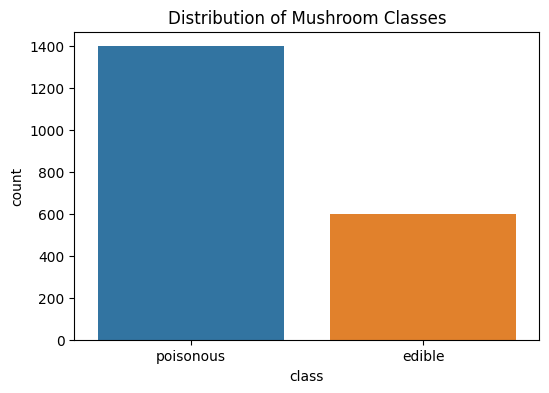

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x="class", hue="class", data=df)
plt.title("Distribution of Mushroom Classes")
plt.show()

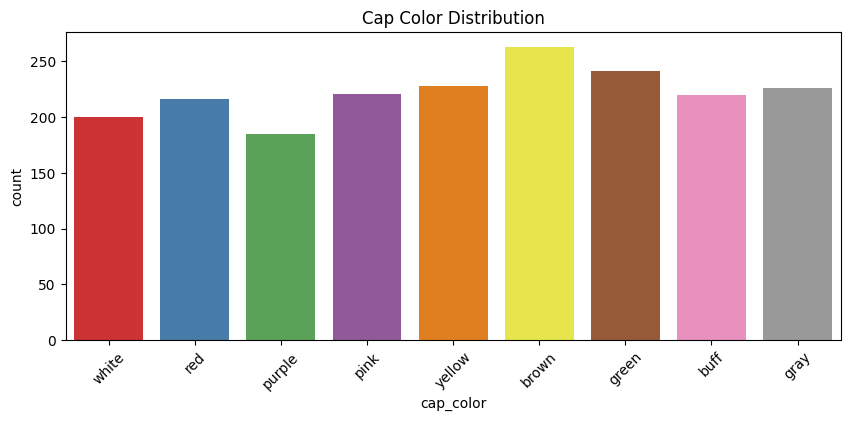

In [11]:
plt.figure(figsize=(10,4))
sns.countplot(x="cap_color", hue="cap_color", data=df,palette="Set1")
plt.title("Cap Color Distribution")
plt.xticks(rotation=45)
plt.show()

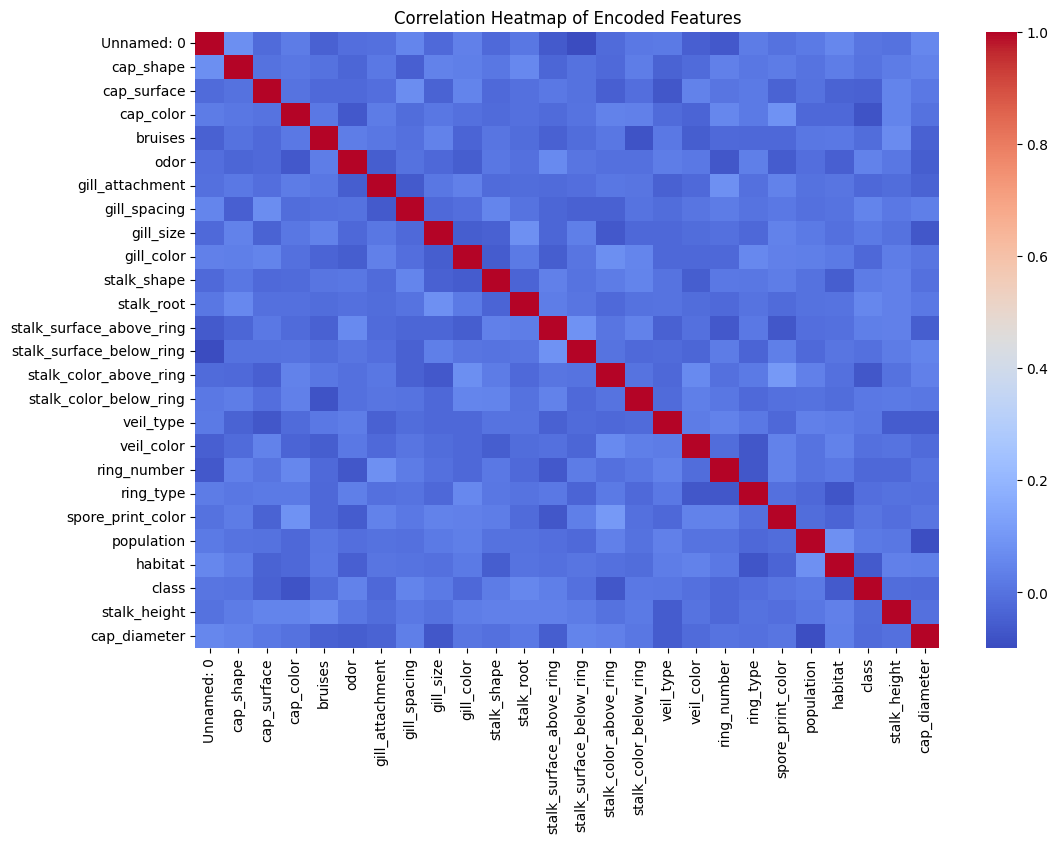

In [12]:
# Correlation after encoding
encoded = df.apply(LabelEncoder().fit_transform)
plt.figure(figsize=(12,8))
sns.heatmap(encoded.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Encoded Features")
plt.show()


- The heatmap shows correlation patterns between encoded categorical features.
- While label encoding assigns numerical values to categories, the correlations should be interpreted cautiously since the features are originally categorical.
- Some features appear moderately correlated, which may influence model performance.

## Data Preprocessing

In [13]:
# Separate features and target
X = df.drop("class", axis=1)
y = df["class"]

# Encode features
X_encoded = X.apply(LabelEncoder().fit_transform)

# Encode target
y_encoded = LabelEncoder().fit_transform(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [15]:
#Scale Features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (1600, 25)
Test shape: (400, 25)


## Data Visualization

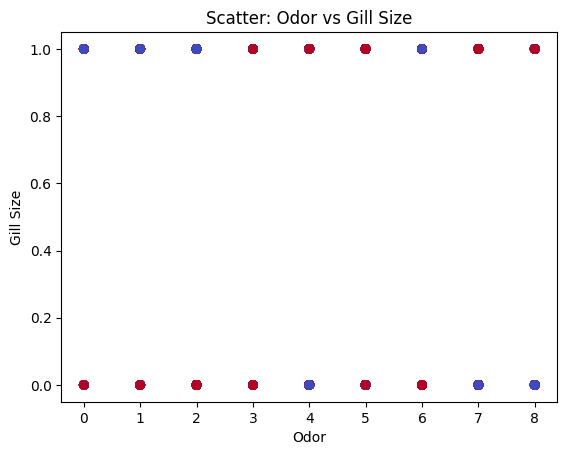

In [16]:
plt.scatter(df_encoded["odor"], df_encoded["gill_size"], c=y_encoded, cmap="coolwarm")
plt.title("Scatter: Odor vs Gill Size")
plt.xlabel("Odor")
plt.ylabel("Gill Size")
plt.show()

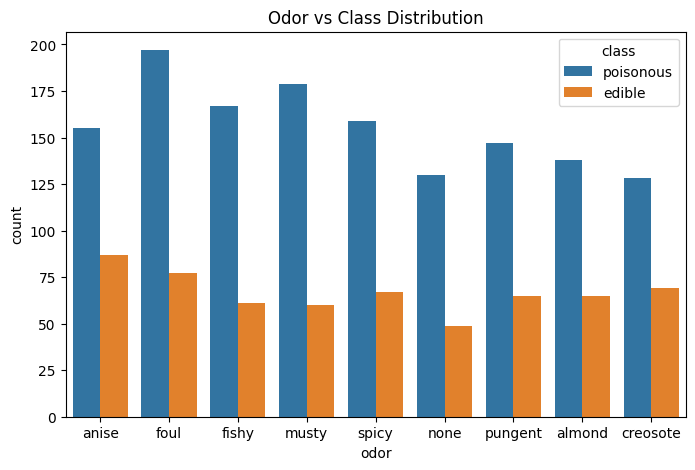

In [17]:
# Odor vs Class
plt.figure(figsize=(8,5))
sns.countplot(x="odor", hue="class", data=df)
plt.title("Odor vs Class Distribution")
plt.show()

The plot shows that certain odor types (such as foul and musty) are more frequently associated with poisonous mushrooms than edible ones.

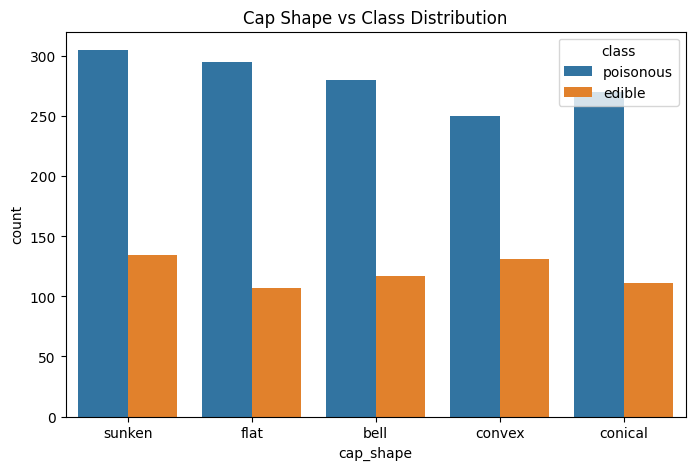

In [18]:
# Cap-shape vs Class
plt.figure(figsize=(8,5))
sns.countplot(x="cap_shape", hue="class", data=df)
plt.title("Cap Shape vs Class Distribution")
plt.show()

The plot shows that poisonous mushrooms are more frequent than edible ones across all cap shapes.

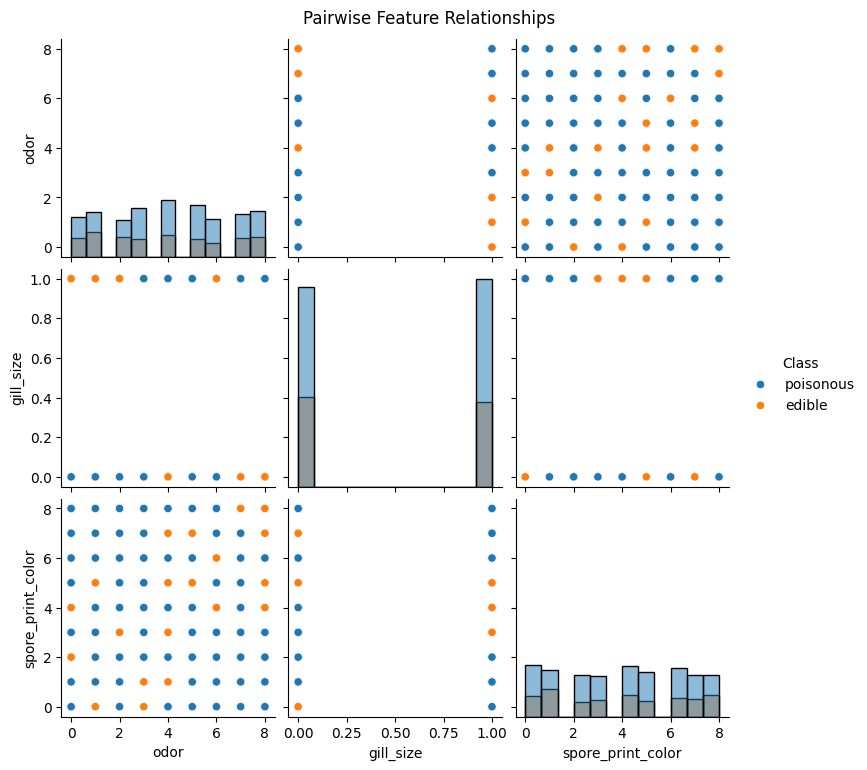

In [19]:
sns.pairplot(
    df_encoded[["odor","gill_size","spore_print_color"]]
        .assign(Class=df["class"]),
    hue="Class",
    diag_kind="hist"
)

plt.suptitle("Pairwise Feature Relationships", y=1.02)
plt.show()

- The pairplot shows how odor, gill size, and spore print color relate to mushroom class.
- There is visible separation between edible and poisonous mushrooms, especially based on odor and spore print color, indicating these features are important for classification.

## SVM Implementation

In [20]:
# Train baseline SVM with RBF kernel
svm_clf = SVC(kernel='rbf', class_weight='balanced', random_state=42) 
svm_clf.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [21]:
# Predictions & evaluation
y_pred_svm = svm_clf.predict(X_test_scaled)

print("SVM (RBF) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

SVM (RBF) Results
Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.62      0.63       120
           1       0.84      0.85      0.84       280

    accuracy                           0.78       400
   macro avg       0.74      0.73      0.74       400
weighted avg       0.78      0.78      0.78       400


Confusion Matrix:
 [[ 74  46]
 [ 42 238]]


## Visualization of SVM Results

In [22]:
# Reduce to 2D using scaled features
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

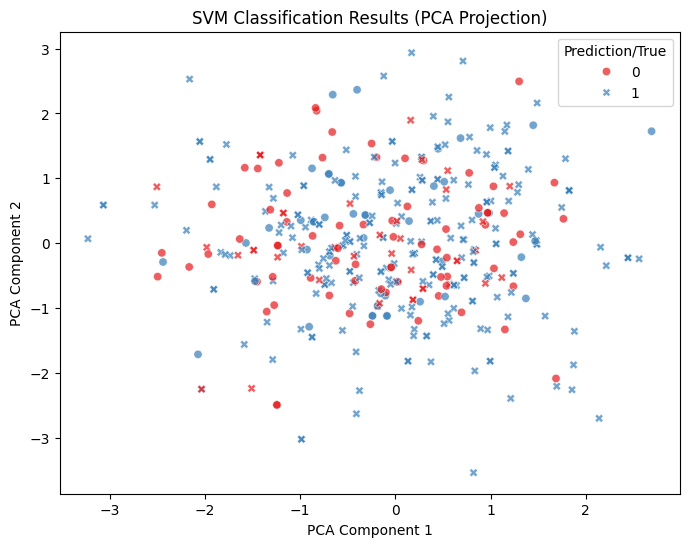

In [23]:
# Predict with SVM (use scaled data)
y_pred_vis = svm_clf.predict(X_test_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_test_pca[:,0],
    y=X_test_pca[:,1],
    hue=y_pred_vis,
    style=y_test,
    palette="Set1",
    alpha=0.7
)

plt.title("SVM Classification Results (PCA Projection)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Prediction/True")
plt.show()

- The PCA projection shows that the two classes overlap in 2D space, which explains why the SVM model does not achieve perfect accuracy.
- Although some separation is visible, many points from both classes are mixed together.

## Parameter Tuning and Optimization

In [24]:
#Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1, 1]
}

grid_search = GridSearchCV(SVC(class_weight="balanced", random_state=42),
                           param_grid, cv=3, scoring="accuracy",
                           n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
Best CV Accuracy: 0.8368818995017954


In [25]:
# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("\nClassification Report (Best Model):\n",
      classification_report(y_test, y_pred_best))
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))


Classification Report (Best Model):
               precision    recall  f1-score   support

           0       1.00      0.53      0.69       120
           1       0.83      1.00      0.91       280

    accuracy                           0.86       400
   macro avg       0.92      0.76      0.80       400
weighted avg       0.88      0.86      0.84       400

Test Accuracy: 0.8575

Confusion Matrix:
 [[ 63  57]
 [  0 280]]


- The tuned SVM model achieved an accuracy of 85.75%, showing significant improvement over the baseline model.
- The RBF kernel provided the best performance, effectively classifying poisonous mushrooms while maintaining overall strong predictive accuracy.

## Comparison & Analysis

In [26]:
models = {
    "Linear": SVC(kernel="linear", C=1, class_weight="balanced", random_state=42),
    "Polynomial": SVC(kernel="poly", degree=3, C=1, gamma=1,
                      class_weight="balanced", random_state=42),
    "RBF": SVC(kernel="rbf", C=1, gamma=1,
               class_weight="balanced", random_state=42)
}
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Kernel Accuracy: {acc:.4f}")

Linear Kernel Accuracy: 0.5625
Polynomial Kernel Accuracy: 0.8550
RBF Kernel Accuracy: 0.8575


- A comparison of different SVM kernels shows that the linear kernel achieved the lowest accuracy (56.25%), indicating that the dataset is not linearly separable.
- The polynomial and RBF kernels performed significantly better, achieving accuracies of 85.50% and 85.75%, respectively.
- Among them, the RBF kernel provided the best overall performance, demonstrating its effectiveness in handling nonlinear patterns in the dataset.

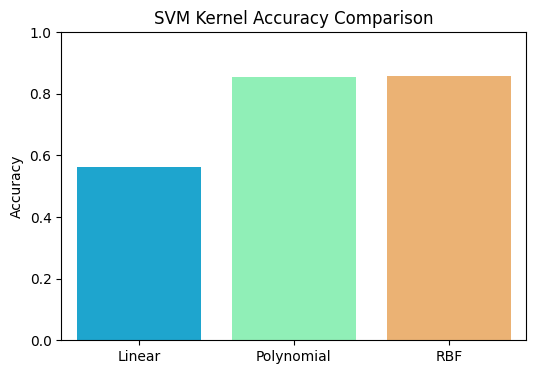

In [27]:
# Bar chart comparison
plt.figure(figsize=(6,4))

sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    hue=list(results.keys()),
    palette="rainbow",
    legend=False
)

plt.ylim(0, 1)
plt.title("SVM Kernel Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

### Analysis of SVM with Different Kernels

- The Linear kernel gave the lowest accuracy (56%), which shows the data is not linearly separable. A straight-line boundary is not enough for this dataset.
- The Polynomial kernel performed much better (around 85%), as it can capture non-linear patterns. However, it is slightly more complex.
- The RBF kernel gave the best results. It achieved around 78% accuracy before tuning and improved to about 86% after tuning.
- This shows that RBF handles complex patterns in the mushroom dataset very well.

**Strengths of SVM for This Dataset**

- SVM works well with high-dimensional data, especially after encoding categorical features.
- It was able to separate poisonous and edible mushrooms effectively.
- After tuning, the model achieved strong accuracy and good F1-scores.

**Weaknesses of SVM for This Dataset**

- SVM is harder to interpret compared to tree-based models.
- Hyperparameter tuning takes extra time.
- It is not very easy to understand which features are most important.

## Conclusion

1. In this project, Support Vector Machine (SVM) was applied to classify mushrooms as edible or poisonous.
2. After preprocessing, encoding, and scaling the data, different SVM kernels were tested and compared.
3. The Linear kernel performed poorly, showing that the dataset is not linearly separable.
4. The Polynomial and RBF kernels performed much better, with the RBF kernel giving the highest accuracy after hyperparameter tuning (about 86%).
5. This confirms that the mushroom dataset contains complex non-linear patterns.

Overall, SVM proved to be an effective model for this classification problem. With proper preprocessing and tuning, it achieved strong predictive performance and showed its ability to handle high-dimensional categorical data.